## Part 1: Exploratory Data Analysis (EDA) and Data Cleaning

### 1.1 Dataset Exploration & Target Cleaning
Target Variable Integrity: Imputation techniques must not be used on the target variable (Weekly_Sales) because doing so can introduce artificial bias into the model's predictions. Lines with missing target values must be dropped completely.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB

--- Summary Statistics ---


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000



Rows before cleaning: 150
Rows after dropping missing target values: 136


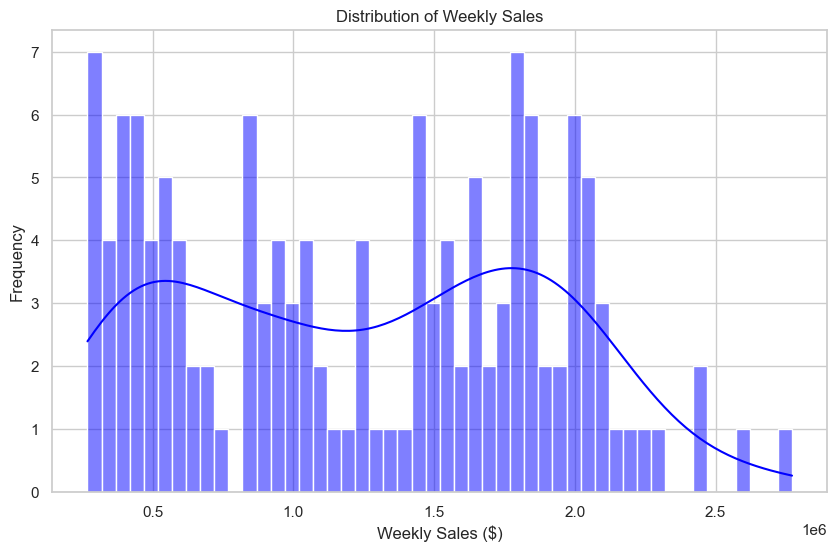

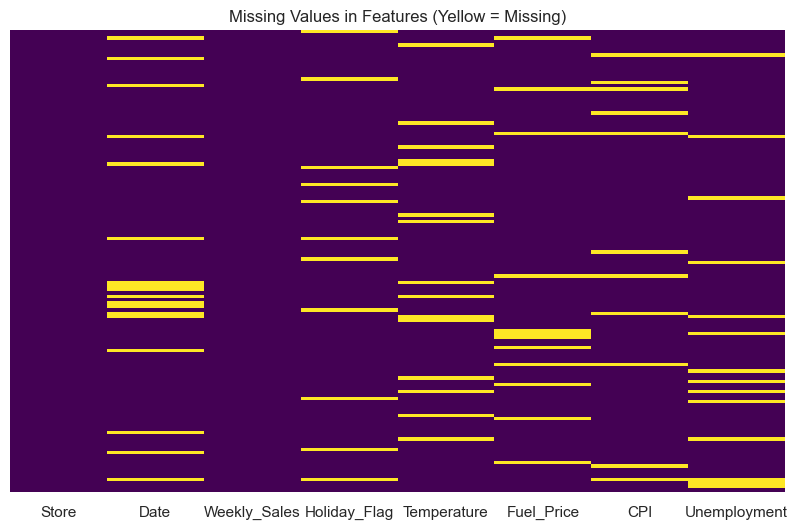

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Load the dataset
# Data file is expected to be located in the data/raw/ directory
file_path = '../data/raw/Walmart_Store_sales.csv'
df = pd.read_csv(file_path)

# 2. Initial Exploration
print("--- Dataset Information ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

# 3. Clean Target Variable
# Drop lines where target values ('Weekly_Sales') are missing.
# Imputation is avoided here to prevent bias in predictions.
df_cleaned = df.dropna(subset=['Weekly_Sales']).copy()

print(f"\nRows before cleaning: {len(df)}")
print(f"Rows after dropping missing target values: {len(df_cleaned)}")

# 4. Basic Visualizations
# Configure plot style
sns.set_theme(style="whitegrid")

# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Weekly_Sales'], bins=50, kde=True, color='blue')
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales ($)')
plt.ylabel('Frequency')
plt.show()

# Observe missing values in other columns
plt.figure(figsize=(10, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values in Features (Yellow = Missing)')
plt.show()

### 1.2 Feature Engineering (Dates) & Outlier Removal
Date Feature Extraction: Machine learning models typically cannot process raw date strings natively. Extracting the Year, Month, Day, and DayOfWeek transforms this temporal data into usable numeric features, allowing the model to capture seasonality and trends.

Outlier Removal: Extreme values can skew the coefficients of a linear regression model. Removing records that fall outside the $[\bar{X} - 3\sigma, \bar{X} + 3\sigma]$ range for specific economic indicators ensures a more robust baseline model.

In [2]:
# --- Phase 2: Feature Engineering & Outlier Removal ---

# 1. Date Feature Extraction
# Convert the 'Date' column to datetime objects
# Note: Format might need adjustment depending on the exact raw CSV format (e.g., dayfirst=True)
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# Extract numeric features from the Date column
df_cleaned['Year'] = df_cleaned['Date'].dt.year
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['DayOfWeek'] = df_cleaned['Date'].dt.dayofweek

# Drop the original 'Date' column as it is no longer needed
df_cleaned = df_cleaned.drop('Date', axis=1)

print("--- Data after Date extraction ---")
display(df_cleaned.head())


# 2. Outlier Removal (3-Sigma Rule)
# Define the columns subject to outlier removal
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print("\n--- Outlier Removal Details ---")
rows_before_outliers = len(df_cleaned)

for col in outlier_cols:
    # Calculate mean and standard deviation
    mean = df_cleaned[col].mean()
    std = df_cleaned[col].std()
    
    # Define bounds
    lower_bound = mean - (3 * std)
    upper_bound = mean + (3 * std)
    
    # Filter out rows outside the bounds. 
    # Missing values (NaNs) are kept here to be handled by the SimpleImputer in the sklearn pipeline later.
    mask = (df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound) | (df_cleaned[col].isnull())
    df_cleaned = df_cleaned[mask]
    
    print(f"{col}: kept values between {lower_bound:.2f} and {upper_bound:.2f}")

rows_after_outliers = len(df_cleaned)
print(f"\nRows removed during outlier filtering: {rows_before_outliers - rows_after_outliers}")
print(f"Total rows remaining: {rows_after_outliers}")


# 3. Separate Target Variable (Y) and Explanatory Variables (X)
target_name = 'Weekly_Sales'

Y = df_cleaned[target_name]
X = df_cleaned.drop(target_name, axis=1)

print("\n--- X and Y Shapes ---")
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

--- Data after Date extraction ---


C:\Users\ENava\AppData\Local\Temp\ipykernel_27936\2807723621.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,4.0



--- Outlier Removal Details ---
Temperature: kept values between 5.31 and 116.40
Fuel_Price: kept values between 1.88 and 4.76
CPI: kept values between 57.36 and 298.82
Unemployment: kept values between 2.81 and 12.52

Rows removed during outlier filtering: 5
Total rows remaining: 131

--- X and Y Shapes ---
X shape: (131, 10)
Y shape: (131,)


In [3]:
# --- Phase 2 Final Step: Export Processed Data ---
import os

# Define output path according to the project structure
output_dir = '../data/processed/'
output_path = os.path.join(output_dir, 'walmart_cleaned.csv')

# Ensure the directory exists
os.makedirs(output_dir, exist_ok=True)

# Export the cleaned dataset (without imputations to prevent data leakage)
df_cleaned.to_csv(output_path, index=False)

print(f"Cleaned data successfully exported to: {output_path}")

Cleaned data successfully exported to: ../data/processed/walmart_cleaned.csv
